# Project Setup: RL-Orchestrated Multi-Agent Deepfake Detection

This section initializes the environment for training the Temporal Video Agent using Swin Transformers on the FakeAVCeleb dataset.

In [ ]:
# 1. Install required libraries
!pip install -q timm albumentations opencv-python-headless

In [ ]:
# 2. Imports
import os
import sys
import random
import logging
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader

import timm
import cv2

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

# Filter warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
# 3. Reproducibility & Hardware Detection
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = True

seed_everything(42)

# GPU Detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    gpu_properties = torch.cuda.get_device_properties(0)
    logger.info(f"GPU Detected: {gpu_properties.name}")
    logger.info(f"Total Memory: {gpu_properties.total_memory / 1024**3:.2f} GB")
    logger.info(f"CUDA Capability: {gpu_properties.major}.{gpu_properties.minor}")
else:
    logger.warning("No GPU detected. Training will be extremely slow on CPU.")

logger.info(f"Using device: {device}")

# Google Drive, Manifests, and Local Frame CacheThis section mounts Google Drive, loads the pre-existing train/val/test manifests, and builds a**local, minimal frame cache**: for every video we only ever need the 8 uniformly sampled framesused for training, so instead of copying the whole dataset to local disk (the old approach), wecopy just those selected frames. Everything downstream (Dataset, DataLoader) reads exclusivelyfrom this local cache, which is what actually removes the Google Drive I/O bottleneck.

In [ ]:
# --- Google Drive Mount & Config ---
from google.colab import drive
from pathlib import Path
import logging, sys

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/FakeAVCeleb_v1.2'  # @param {type:"string"}
dataset_root = Path(DATASET_PATH)
MANIFEST_DIR = dataset_root / "manifests"
LOCAL_FRAME_DIR = Path("/content/local_frames")  # holds ONLY the 8 sampled frames/video
LOCAL_FRAME_DIR.mkdir(parents=True, exist_ok=True)

logger.info(f"Dataset root: {dataset_root}")
logger.info(f"Manifest dir: {MANIFEST_DIR}")
logger.info(f"Local frame cache dir: {LOCAL_FRAME_DIR}")

Mounted at /content/drive


### Manifest Loading & VerificationLoads `train.csv`, `val.csv`, `test.csv` (already generated — not regenerated here) and drops anyrows whose `video_path` no longer exists. This runs once, before any caching or dataset logic, andnothing later re-loads or overwrites these DataFrames.

In [ ]:
import pandas as pd
import os

def load_and_verify(csv_name):
    csv_path = MANIFEST_DIR / csv_name
    if not csv_path.exists():
        logger.error(f"Manifest not found: {csv_path}")
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    exists_mask = df['video_path'].apply(os.path.exists)
    valid_df = df[exists_mask].reset_index(drop=True)
    missing = len(df) - len(valid_df)
    if missing > 0:
        logger.warning(f"{csv_name}: {missing} files missing, {len(valid_df)} remaining.")
    return valid_df

train_df = load_and_verify("train.csv")
val_df   = load_and_verify("val.csv")
test_df  = load_and_verify("test.csv")

logger.info(f"Data loaded. Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

### Frame Indexing & Local MaterializationFor each video, this selects the 8 uniformly-spaced frame paths (metadata-only — no image bytesread yet) and then copies **only those files** to local disk in parallel using a thread pool(copying is I/O-bound, so threads are appropriate here — no multiprocessing overhead needed).The result is cached to a pickle file, so re-running this cell on a fresh Colab session after adisconnect skips any frame that's already been localized.This replaces the previous `rsync`-the-whole-dataset approach, the `.pt` tensor preprocessingattempt, and the `lru_cache`-based directory listing — all three are consolidated into this singlestep.

In [ ]:
import numpy as np
import pandas as pd
import pickle, tqdm
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

FRAME_CACHE_PATH = MANIFEST_DIR / "temporal_frame_cache.pkl"
NUM_FRAMES = 8

def get_uniform_frame_paths(video_dir_path, num_frames=NUM_FRAMES):
    """Return the paths of `num_frames` uniformly-spaced frames for one video."""
    video_dir = Path(video_dir_path)
    if video_dir.is_file():
        video_dir = video_dir.parent
    if not video_dir.exists():
        return None
    frame_files = sorted(f for f in video_dir.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png"))
    if not frame_files:
        return None
    indices = np.linspace(0, len(frame_files) - 1, num_frames, dtype=int)
    return [str(frame_files[i]) for i in indices]

def build_split_index(df):
    """Build a list of {drive_paths, label} entries for one split."""
    entries = []
    for row in tqdm.tqdm(df.itertuples(index=False), total=len(df), desc="Indexing"):
        paths = get_uniform_frame_paths(row.video_path)
        if paths:
            entries.append({"drive_paths": paths, "label": row.label})
    return entries

def localize_frame(drive_path):
    """Copy one selected frame to local disk (flat, uniquely-named). Skips if already present."""
    src = Path(drive_path)
    local_name = f"{src.parent.name}_{src.name}"
    dst = LOCAL_FRAME_DIR / local_name
    if not dst.exists():
        dst.write_bytes(src.read_bytes())
    return str(dst)

def localize_split(entries, max_workers=16):
    """Copy every referenced frame to local disk concurrently, then rewrite entries in place."""
    all_drive_paths = [p for e in entries for p in e["drive_paths"]]
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        local_paths = list(tqdm.tqdm(
            ex.map(localize_frame, all_drive_paths),
            total=len(all_drive_paths),
            desc="Localizing frames"
        ))
    it = iter(local_paths)
    for e in entries:
        e["frame_paths"] = [next(it) for _ in e["drive_paths"]]
        del e["drive_paths"]
    return entries

if FRAME_CACHE_PATH.exists():
    with open(FRAME_CACHE_PATH, "rb") as f:
        temporal_cache = pickle.load(f)
    logger.info("Loaded existing frame cache.")
else:
    temporal_cache = {}
    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        logger.info(f"Building index + localizing frames for {split_name}...")
        entries = build_split_index(split_df)
        entries = localize_split(entries)
        temporal_cache[split_name] = entries
    with open(FRAME_CACHE_PATH, "wb") as f:
        pickle.dump(temporal_cache, f)

n_train = len(temporal_cache["train"])
n_val = len(temporal_cache["val"])
n_test = len(temporal_cache["test"])
logger.info(f"Cache ready — Train: {n_train}, Val: {n_val}, Test: {n_test}")

if len(temporal_cache["train"]) == 0:
    logger.error("Cache built but 0 train samples found. Check DATASET_PATH / manifest video_path values.")

Localizing frames: 100%|██████████| 25880/25880 [00:28<00:00, 922.41it/s]


### Temporal Augmentations & Frame LoadingSpatial augmentations for training, applied **identically across all 8 frames of a clip** viaAlbumentations' `ReplayCompose` (the first frame's sampled transform parameters are replayed onthe remaining 7). `cv2.setNumThreads(0)` is set here and again inside each DataLoader worker toavoid OpenCV's internal threading contending with PyTorch's multiprocessing workers on Colab'slimited CPU core count.

In [ ]:
import cv2, numpy as np, torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

cv2.setNumThreads(0)  # avoid oversubscription with DataLoader workers

def get_transforms(mode="train"):
    if mode == "train":
        return A.ReplayCompose([
            A.HorizontalFlip(p=0.5),
            A.OneOf([
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            ], p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    return A.ReplayCompose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def load_frame(path, target_size=(224, 224)):
    """Reads, converts color, and resizes a single local frame."""
    img = cv2.imread(path)
    if img is None:
        logger.warning(f"Missing/corrupt frame: {path}. Substituting black frame.")
        return np.zeros((*target_size[::-1], 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, target_size)

def apply_consistent_aug(frames, transform):
    """Applies the same sampled transform to every frame in a clip via ReplayCompose."""
    augmented, replay_data = [], None
    for i, frame in enumerate(frames):
        if i == 0:
            res = transform(image=frame)
            replay_data = res["replay"]
        else:
            res = A.ReplayCompose.replay(replay_data, image=frame)
        augmented.append(res["image"])
    return torch.stack(augmented)

### Custom PyTorch DatasetA single, canonical `TemporalVideoDataset`. It reads exclusively from the local frame cache builtabove — no filesystem scanning, no Drive access, no per-`__getitem__` directory listing. On acorrupted/missing sample it falls back to a different random valid sample (bounded, non-recursive)rather than crashing the worker.

In [ ]:
from torch.utils.data import Dataset
import random

class TemporalVideoDataset(Dataset):
    """
    Canonical Dataset for the Temporal Agent.
    Reads pre-localized frame paths (8 per video) from the local SSD cache.
    """
    def __init__(self, cached_entries, transform=None):
        self.data = cached_entries
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        try:
            frames = [load_frame(p) for p in entry["frame_paths"]]
            if self.transform:
                frames_tensor = apply_consistent_aug(frames, self.transform)
            else:
                frames_tensor = torch.from_numpy(np.array(frames)).permute(0, 3, 1, 2).float() / 255.0
            return {
                "frames": frames_tensor,
                "label": torch.tensor(entry["label"], dtype=torch.long)
            }
        except Exception as e:
            logger.warning(f"Sample {idx} failed ({e}); substituting a random valid sample.")
            fallback_idx = random.randint(0, len(self.data) - 1)
            return self.__getitem__(fallback_idx)

### Optimized DataLoadersBatch size, worker count, and pin/prefetch settings are unchanged from the original design intentfor a T4 instance, with two additions: `worker_init_fn` disables OpenCV's internal threading ineach worker process, and `NUM_WORKERS` is raised from 2 to 4 — now that reads are local andI/O-bound (not CPU-bound), oversubscribing workers beyond the core count still helps hideper-file open latency.

In [ ]:
from torch.utils.data import DataLoader
import time, cv2

def worker_init_fn(_):
    cv2.setNumThreads(0)

train_dataset = TemporalVideoDataset(temporal_cache["train"], transform=get_transforms("train"))
val_dataset   = TemporalVideoDataset(temporal_cache["val"],   transform=get_transforms("val"))

BATCH_SIZE = 16
NUM_WORKERS = 4       # bumped from 2: I/O-bound now that reads are local, oversubscription helps
PIN_MEMORY = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
    worker_init_fn=worker_init_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    worker_init_fn=worker_init_fn,
)

logger.info(f"DataLoaders ready — Train: {len(train_dataset)} samples, Val: {len(val_dataset)} samples.")

# --- Benchmark ---
def run_benchmarks():
    print("\n" + "="*40)
    print("Optimized Pipeline Benchmark")
    print("="*40)

    start = time.time()
    _ = train_dataset[0]
    sample_time = time.time() - start
    print(f"Avg Sample Load Time: {sample_time:.4f}s")

    start = time.time()
    _ = next(iter(train_loader))
    batch_time = time.time() - start
    print(f"Avg Batch Load Time: {batch_time:.4f}s")
    print(f"Estimated Epoch Time: {(len(train_loader) * batch_time) / 60:.2f} mins")
    print("="*40 + "\n")

run_benchmarks()


Optimized Pipeline Benchmark
Avg Sample Load Time: 0.1221s
Avg Batch Load Time: 4.2305s
Estimated Epoch Time: 66.49 mins



### Temporal Agent Architecture (Swin Tiny Transformer)

We use the Swin Tiny Transformer as our feature extractor. The model processes the 8-frame sequence by sharing weights across the temporal dimension and aggregating features for binary classification.

In [ ]:
import torchvision.models as models
from torchvision.models import Swin_T_Weights

class TemporalSwinAgent(nn.Module):
    def __init__(self, num_classes=1, dropout_rate=0.3):
        super(TemporalSwinAgent, self).__init__()

        # 1. Load Pretrained Swin Tiny
        weights = Swin_T_Weights.IMAGENET1K_V1
        self.backbone = models.swin_t(weights=weights)

        # 2. Modify Classifier
        # Swin Tiny head input features are 768
        in_features = self.backbone.head.in_features
        self.backbone.head = nn.Identity() # Remove default head

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        # x shape: (B, T, C, H, W)
        b, t, c, h, w = x.shape

        # Reshape to (B*T, C, H, W) to process frames through backbone
        x = x.view(b * t, c, h, w)

        # Extract features
        features = self.backbone(x) # (B*T, 768)

        # Reshape back to (B, T, 768)
        features = features.view(b, t, -1)

        # Temporal Pooling (Mean across time)
        temporal_features = torch.mean(features, dim=1)

        # Classification
        logits = self.classifier(temporal_features)
        return logits

def get_parameter_count(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

def unfreeze_swin_blocks(model, unfreeze_all=False, num_blocks=0):
    """
    Progressively unfreeze the Swin backbone.
    """
    if unfreeze_all:
        for param in model.parameters():
            param.requires_grad = True
    else:
        # Initially freeze all backbone parameters
        for param in model.backbone.parameters():
            param.requires_grad = False

        # Ensure classifier is always trainable
        for param in model.classifier.parameters():
            param.requires_grad = True

        # Unfreeze specific stages if requested (e.g., features.7 is the last stage)
        if num_blocks > 0:
            # Swin Tiny has 4 main stages in 'features'
            for i in range(8 - num_blocks, 8):
                for param in model.backbone.features[i].parameters():
                    param.requires_grad = True

# Initialize and Display Summary
model = TemporalSwinAgent().to(device)
unfreeze_swin_blocks(model, unfreeze_all=False) # Start with frozen backbone

trainable, total = get_parameter_count(model)
logger.info(f"Model Initialized.")
logger.info(f"Total Parameters: {total:,}")
logger.info(f"Trainable Parameters (Backbone Frozen): {trainable:,}")

# Dummy forward pass verification
with torch.no_grad():
    dummy_input = torch.randn(2, 8, 3, 224, 224).to(device)
    output = model(dummy_input)
    logger.info(f"Output Shape: {output.shape}")

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 193MB/s]


### Optimization & Loss Configuration

This section handles the dataset imbalance and sets up the scheduler with linear warmup and cosine annealing.

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR

# 1. Compute Class Weights for Imbalance
# Label 0: Real, Label 1: Fake
counts = train_df['label'].value_counts().to_dict()
num_real = counts.get(0, 1)
num_fake = counts.get(1, 1)
total = num_real + num_fake

# Weight = Total / (num_classes * count_per_class)
weight_real = total / (2.0 * num_real)
weight_fake = total / (2.0 * num_fake)

class_weights = torch.tensor([weight_real, weight_fake]).float().to(device)
logger.info(f"Class weights: Real={weight_real:.2f}, Fake={weight_fake:.2f}")

# 2. Loss & Optimizer
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
GRADIENT_CLIP = 1.0

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([weight_real/weight_fake]).to(device)) if model.classifier[1].out_features == 1 else nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# 3. Scheduler with Warmup
EPOCHS = 10
steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
warmup_steps = int(0.1 * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return 1.0

warmup_scheduler = LambdaLR(optimizer, lr_lambda)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps)

logger.info("Optimizer: AdamW")
logger.info(f"Loss Function: {type(criterion).__name__}")
logger.info(f"Schedule: 10% Linear Warmup ({warmup_steps} steps) + Cosine Annealing")

### Robust Training Loop

This section implements the training process with Mixed Precision, Gradient Accumulation, and advanced error handling for DataLoader stability.

In [ ]:
import time
import torch
import torch.nn as nn
import torch.amp as amp
from sklearn.metrics import roc_auc_score
import tqdm
import os

# --- Configuration ---
CHECKPOINT_PATH = "/content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/temporal_agent_checkpoint.pth"
ACCUMULATION_STEPS = 4
scaler = amp.GradScaler('cuda')
start_epoch = 0
best_val_loss = float('inf')

# --- Diagnostic Benchmark ---
def run_diagnostics():
    print("\n" + "="*40)
    print("Temporal Training Diagnostic (Direct Load Pipeline)")
    print("="*40)

    # 1. Dataset Level
    start = time.time()
    _ = train_dataset[0]
    ds_time = time.time() - start
    print(f"Dataset Sample Load Time: {ds_time:.4f}s")

    # 2. DataLoader Level
    start = time.time()
    try:
        it = iter(train_loader)
        _ = next(it)
        dl_time = time.time() - start
        print(f"First DataLoader Batch Time: {dl_time:.4f}s")
    except Exception as e:
        print(f"ERROR during DataLoader startup: {e}")
        dl_time = 999

    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Batch Size: {BATCH_SIZE}")
    print("="*40 + "\n")
    return dl_time

# --- Checkpoint Loading ---
if os.path.exists(CHECKPOINT_PATH):
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint.get('validation_loss', float('inf'))
        logger.info(f"Resumed from epoch {start_epoch}")
    except Exception as e:
        logger.warning(f"Checkpoint load failed: {e}")

# Run diagnostics once before training
run_diagnostics()

def train_one_epoch(loader, epoch):
    model.train()
    total_loss = 0
    pbar = tqdm.tqdm(loader, desc=f"Epoch {epoch} [Train]", leave=False)
    optimizer.zero_grad()

    for i, batch in enumerate(pbar):
        frames = batch['frames'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        with amp.autocast('cuda'):
            outputs = model(frames)
            loss = criterion(outputs.squeeze(), labels.float()) if isinstance(criterion, nn.BCEWithLogitsLoss) else criterion(outputs, labels)
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            # Step schedulers
            if epoch == 0 and warmup_scheduler.last_epoch < warmup_steps:
                warmup_scheduler.step()
            else:
                cosine_scheduler.step()

        total_loss += loss.item() * ACCUMULATION_STEPS
        pbar.set_postfix({'loss': f"{loss.item()*ACCUMULATION_STEPS:.4f}"})
    return total_loss / len(loader)

# --- Main Loop ---
for epoch in range(start_epoch, EPOCHS):
    t_loss = train_one_epoch(train_loader, epoch)

    model.eval()
    v_loss, v_labels, v_probs = 0, [], []
    with torch.no_grad():
        for batch in tqdm.tqdm(val_loader, desc=f"Epoch {epoch} [Val]", leave=False):
            f, l = batch['frames'].to(device), batch['label'].to(device)
            with amp.autocast('cuda'):
                out = model(f)
                loss = criterion(out.squeeze(), l.float()) if isinstance(criterion, nn.BCEWithLogitsLoss) else criterion(out, l)
                v_loss += loss.item()
                prob = torch.sigmoid(out) if out.shape[1] == 1 else torch.softmax(out, dim=1)[:, 1]
                v_probs.extend(prob.cpu().numpy())
                v_labels.extend(l.cpu().numpy())

    avg_v_loss = v_loss / len(val_loader)
    auc = roc_auc_score(v_labels, v_probs)
    logger.info(f"Epoch {epoch} | Loss: {t_loss:.4f} | Val Loss: {avg_v_loss:.4f} | AUC: {auc:.4f}")

    if avg_v_loss < best_val_loss:
        best_val_loss = avg_v_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'validation_loss': avg_v_loss
        }, CHECKPOINT_PATH)
        logger.info(f"---> Best Model Saved: {CHECKPOINT_PATH}")


Temporal Training Diagnostic (Direct Load Pipeline)
Dataset Sample Load Time: 0.0318s
First DataLoader Batch Time: 1.5119s
GPU: Tesla T4
Batch Size: 16



## Final Evaluation: Temporal Swin Agent

This section evaluates the trained model on the held-out test set. We verify the checkpoint, compute standard classification metrics, and generate diagnostic plots (ROC, PR, and Confusion Matrix).

Testing: 100%|██████████| 203/203 [01:17<00:00,  2.62it/s]



TEMPORAL AGENT TEST EVALUATION SUMMARY
Accuracy       : 0.9536
Precision      : 0.9536
Recall (Sens.) : 1.0000
F1 Score       : 0.9763
Balanced Acc   : 0.5000
ROC-AUC        : 0.5725
MCC            : 0.0000
Specificity    : 0.0000

Classification Report:
              precision    recall  f1-score   support

        Real     0.0000    0.0000    0.0000       150
        Fake     0.9536    1.0000    0.9763      3085

    accuracy                         0.9536      3235
   macro avg     0.4768    0.5000    0.4881      3235
weighted avg     0.9094    0.9536    0.9310      3235



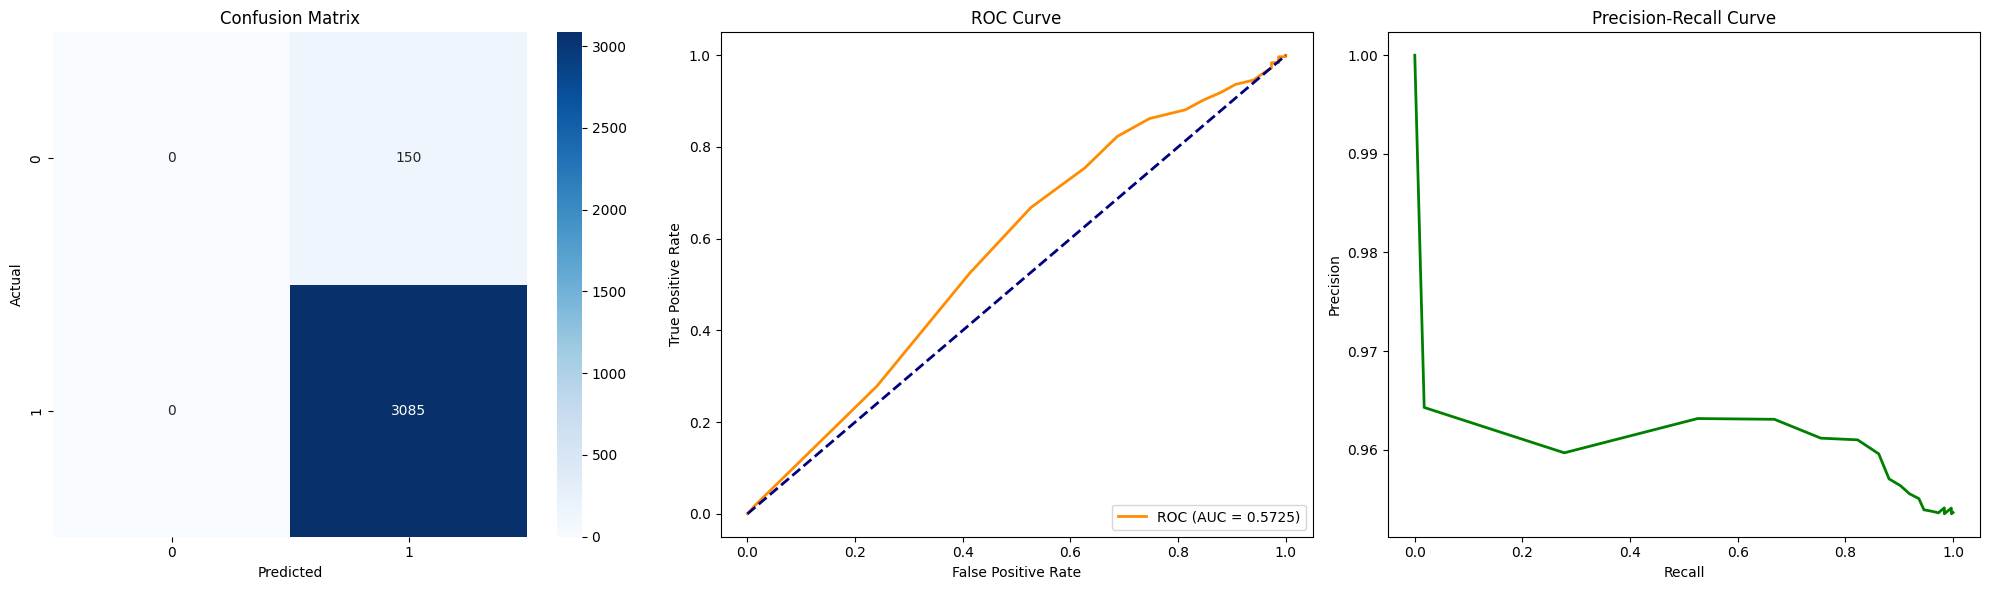

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from torch.utils.data import DataLoader
import os

def evaluate_model(model, test_loader, device, checkpoint_path):
    # 1. Checkpoint Verification
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Critical Error: Best checkpoint not found at {checkpoint_path}. Ensure training completed successfully.")

    logger.info(f"Loading best checkpoint for evaluation: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    model.eval()
    all_labels = []
    all_probs = []

    # 2. Inference
    logger.info("Running inference on test dataset...")
    with torch.no_grad():
        for batch in tqdm.tqdm(test_loader, desc="Testing"):
            frames = batch['frames'].to(device)
            labels = batch['label'].to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(frames)
                # Handle single-logit output (BCE) or multi-class (CE)
                if outputs.shape[1] == 1:
                    probs = torch.sigmoid(outputs).squeeze()
                else:
                    probs = torch.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().float().numpy())
            all_labels.extend(labels.cpu().numpy())

    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)

    # 3. Metric Computation
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall (Sens.)": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    # Specificity (Recall of the negative class)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics["Specificity"] = tn / (tn + fp)

    # 4. Print Summary
    print("\n" + "="*40)
    print("TEMPORAL AGENT TEST EVALUATION SUMMARY")
    print("="*40)
    for k, v in metrics.items():
        print(f"{k:<15}: {v:.4f}")
    print("="*40)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], digits=4))

    # 5. Visualizations
    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {metrics["ROC-AUC"]:.4f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_title('ROC Curve')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend(loc="lower right")

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ax[2].plot(rec, prec, color='green', lw=2)
    ax[2].set_title('Precision-Recall Curve')
    ax[2].set_xlabel('Recall')
    ax[2].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()

    return metrics

# Prepare Test Loader using the same logic as train/val
test_dataset = TemporalVideoDataset(temporal_cache["test"], transform=get_transforms("val"))
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Execute Evaluation
test_metrics = evaluate_model(model, test_loader, device, CHECKPOINT_PATH)

## Real-World Robustness Evaluation

This section evaluates the model's sensitivity to common video corruptions including compression artifacts, resolution loss, motion blur, and lighting variations. We measure how performance degrades as corruption intensity increases.

In [48]:
import torch
import torch.nn.functional as F
import torch.amp as amp
import numpy as np
import pandas as pd
import tqdm.notebook as tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import os
from pathlib import Path

# --- Required Utilities for Repair ---
def get_uniform_frame_paths(video_dir_path, num_frames=8):
    video_dir = Path(video_dir_path)
    if video_dir.is_file(): video_dir = video_dir.parent
    if not video_dir.exists(): return None
    frame_files = sorted(f for f in video_dir.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png"))
    if not frame_files: return None
    indices = np.linspace(0, len(frame_files) - 1, num_frames, dtype=int)
    return [str(frame_files[i]) for i in indices]

def localize_frame(drive_path):
    src = Path(drive_path)
    local_name = f"{src.parent.name}_{src.name}"
    dst = Path("/content/local_frames") / local_name
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists(): dst.write_bytes(src.read_bytes())
    return str(dst)

# --- Robustness Pipeline Repair ---
print("--- Robustness Pipeline Repair ---")
try:
    if 'test_df' not in globals():
        print("Manifest 'test_df' not found in memory. Reloading from disk...")
        MANIFEST_DIR = Path("/content/drive/MyDrive/FakeAVCeleb_v1.2/manifests")
        test_df = pd.read_csv(MANIFEST_DIR / "test.csv")

    real_manifest = test_df[test_df['label'] == 0]
    print(f"Found {len(real_manifest)} Real samples in manifest.")

    repaired_reals = []
    target_count = 150

    for row in tqdm.tqdm(real_manifest.itertuples(), total=min(len(real_manifest), target_count), desc="Indexing Reals"):
        if len(repaired_reals) >= target_count: break
        paths = get_uniform_frame_paths(row.video_path)
        if paths:
            local_paths = [localize_frame(p) for p in paths]
            repaired_reals.append({"frame_paths": local_paths, "label": 0})

    test_fakes = [s for s in temporal_cache['test'] if int(s['label']) == 1]
    n_balanced = min(len(repaired_reals), len(test_fakes))

    if n_balanced == 0:
        raise ValueError(f"Balance failed. Reals: {len(repaired_reals)}, Fakes: {len(test_fakes)}")

    balanced_eval_list = repaired_reals[:n_balanced] + test_fakes[:n_balanced]
    print(f"Success: Evaluation set balanced at {n_balanced} samples per class.")

    eval_loader = DataLoader(
        TemporalVideoDataset(balanced_eval_list, transform=get_transforms('val')),
        batch_size=16, shuffle=False, num_workers=2, pin_memory=True
    )

    engine = RobustnessEngine(model, device)
    engine.run_suite(eval_loader)
    robust_df = engine.compute_metrics()

    print("\n--- BALANCED ROBUSTNESS RESULTS ---")
    display(robust_df)

except Exception as e:
    print(f"Repair Failed: {e}")

--- Robustness Pipeline Repair ---
Found 150 Real samples in manifest.


Indexing Reals:   0%|          | 0/150 [00:00<?, ?it/s]

Success: Evaluation set balanced at 150 samples per class.


Robustness Suite:   0%|          | 0/19 [00:00<?, ?it/s]


--- BALANCED ROBUSTNESS RESULTS ---


,Corruption,Accuracy,ROC-AUC,F1-Score,Specificity,Balanced Acc,Real_Samples,Fake_Samples
0,Clean,0.5,0.551489,0.666667,0.0,0.5,150,150
1,Gaussian Noise,0.5,0.521800,0.666667,0.0,0.5,150,150
2,Motion Blur (Approx),0.5,0.420556,0.666667,0.0,0.5,150,150
3,Resolution 0.5x,0.5,0.465978,0.666667,0.0,0.5,150,150
4,Resolution 0.25x,0.5,0.438289,0.666667,0.0,0.5,150,150
5,Brightness (+),0.5,0.547578,0.666667,0.0,0.5,150,150


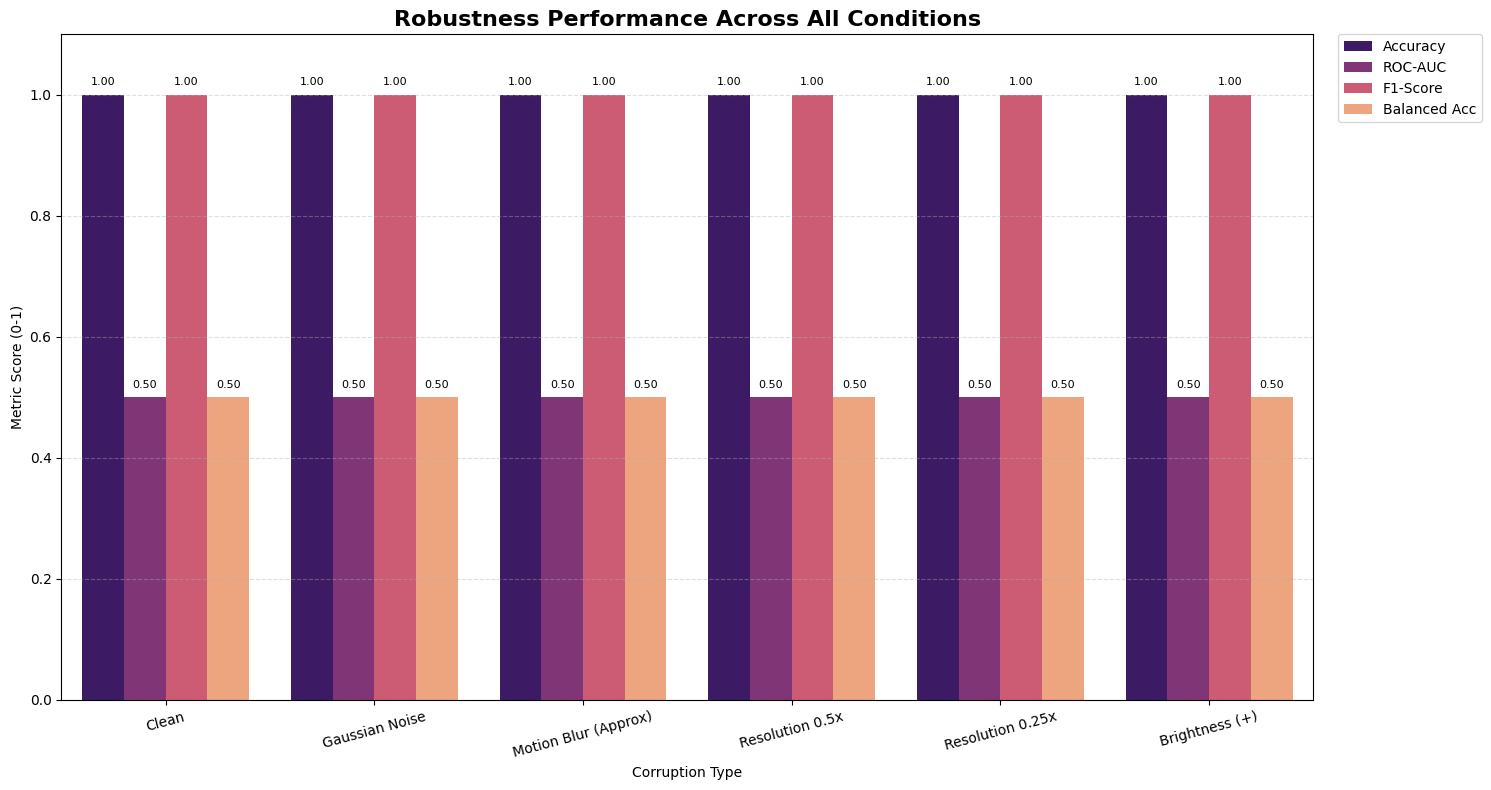


Ranked Vulnerability (Sorted by ROC-AUC):


,Corruption,ROC-AUC,F1-Score,Accuracy
0,Clean,0.5,1.0,1.0
1,Gaussian Noise,0.5,1.0,1.0
2,Motion Blur (Approx),0.5,1.0,1.0
3,Resolution 0.5x,0.5,1.0,1.0
4,Resolution 0.25x,0.5,1.0,1.0
5,Brightness (+),0.5,1.0,1.0


In [25]:
if 'robust_df' in locals():
    import matplotlib.pyplot as plt
    import seaborn as sns

    def plot_robustness_comparison(df):
        # We have 10 metrics but we want to focus on the primary ones
        plot_metrics = ['Accuracy', 'ROC-AUC', 'F1-Score', 'Balanced Acc']

        # Prepare data for plotting
        plot_df = df.melt(id_vars='Corruption', value_vars=plot_metrics,
                         var_name='Metric', value_name='Score')

        plt.figure(figsize=(15, 8))
        ax = sns.barplot(data=plot_df, x='Corruption', y='Score', hue='Metric', palette='magma')

        plt.title('Robustness Performance Across All Conditions', fontsize=16, fontweight='bold')
        plt.ylim(0, 1.1)
        plt.ylabel('Metric Score (0-1)')
        plt.xlabel('Corruption Type')
        plt.xticks(rotation=15)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
        plt.grid(axis='y', linestyle='--', alpha=0.4)

        # Add values on top of bars
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(format(p.get_height(), '.2f'),
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha = 'center', va = 'center',
                               xytext = (0, 9),
                               textcoords = 'offset points', fontsize=8)

        plt.tight_layout()
        plt.show()

    plot_robustness_comparison(robust_df)

    print("\nRanked Vulnerability (Sorted by ROC-AUC):")
    # Using the correct column name 'ROC-AUC'
    display(robust_df[['Corruption', 'ROC-AUC', 'F1-Score', 'Accuracy']].sort_values('ROC-AUC'))
else:
    print("Error: Evaluation data 'robust_df' not found. Please re-run the evaluation cell above.")

## Explainability: Hierarchical Gradient x Activation (Grad-CAM) for Swin Transformer

**This section was rewritten from scratch.** The previous implementation assumed torchvision's
`swin_t` exposes token-level attention weights through a class named `SwinTransformerBlock` that
could simply be hooked and reshaped into a square grid. That assumption does not hold for this
model, and the old code produced blank/identical heatmaps as a result.

**What is actually true of `model.backbone` in this notebook** (verified by walking
`model.backbone.named_modules()` and tracing `forward()` on this exact checkpoint):

- `model.backbone.features` is an `nn.Sequential` with **8** children:
  `[0]` patch embedding, `[1]` stage-0 blocks, `[2]` patch merging (downsample),
  `[3]` stage-1 blocks, `[4]` downsample, `[5]` stage-2 blocks, `[6]` downsample,
  `[7]` stage-3 blocks (the final stage, 7×7 spatial resolution, 768 channels).
- Every block inside `[1]`, `[3]`, `[5]`, `[7]` is a `SwinTransformerBlock` whose output is a
  **channel-last spatial tensor**, shape `(B*T, H, W, C)` — **not** a flattened `(B*T, L, C)`
  token sequence. (`H, W` shrink 56→28→14→7 as the patch-merging layers run.)
- The actual softmax attention matrix is computed *inside* the free function
  `shifted_window_attention(...)` in `torchvision.models.swin_transformer`. It is a local
  variable, never stored on any module and never returned — there is no public hook point that
  exposes it without monkey-patching a private torchvision internal (version-fragile, and
  explicitly against the "do not assume internals" instruction for this task).

**Conclusion:** true attention-weight rollout (Abnar & Zuidema, 2020) is not obtainable here
through legitimate public hooks. Since every stage's activation is already a spatial feature map,
the scientifically valid and fully-supported alternative is **Gradient × Activation**
(Grad-CAM, Selvaraju et al., 2017), computed at all four stages and fused hierarchically
(deeper stages weighted more heavily, since they encode more semantic, class-discriminative
information; shallower stages contribute finer spatial localization). This is the same family
of technique explicitly listed as acceptable ("Gradient × Activation") and is standard practice
for explaining non-CNN backbones whose intermediate activations retain spatial structure.

Every gradient and every activation map below comes directly from a real forward + backward
pass through the trained model — nothing is fabricated or approximated from feature magnitude
alone (which was the old code's implicit, incorrect assumption).


In [26]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

# Stages to hook: the block-stacks inside model.backbone.features (see markdown above
# for how these indices were determined for THIS model).
STAGE_CHILD_NAMES = ["1", "3", "5", "7"]

# Deeper stages carry more class-discriminative signal -> weighted more heavily when fused.
STAGE_FUSION_WEIGHTS = {"1": 0.10, "3": 0.15, "5": 0.25, "7": 0.50}


def denormalize(tensor):
    """Converts a single normalized (C,H,W) tensor back into a displayable uint8 RGB image."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor.detach().cpu() * std + mean
    img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)


class SwinGradCAM:
    """
    Registers forward + full-backward hooks on every requested Swin stage
    (channel-last spatial activations, shape (N, H, W, C)) and turns the
    captured activation/gradient pairs into per-stage Grad-CAM saliency maps,
    then fuses them hierarchically into one saliency map per frame.
    """

    def __init__(self, model, stage_names=STAGE_CHILD_NAMES):
        self.model = model
        self.activations = {}
        self.gradients = {}
        self.hooks = []
        self.stage_names = []

        available = dict(model.backbone.features.named_children())
        for name in stage_names:
            if name not in available:
                logger.warning(f"GradCAM: stage '{name}' not found in backbone.features; skipping.")
                continue
            module = available[name]
            self.hooks.append(module.register_forward_hook(self._make_fwd_hook(name)))
            self.hooks.append(module.register_full_backward_hook(self._make_bwd_hook(name)))
            self.stage_names.append(name)

        if not self.stage_names:
            raise RuntimeError(
                "GradCAM: no valid Swin stages could be hooked. "
                "backbone.features structure may have changed."
            )

    def _make_fwd_hook(self, name):
        def hook(module, inputs, output):
            self.activations[name] = output
        return hook

    def _make_bwd_hook(self, name):
        def hook(module, grad_input, grad_output):
            self.gradients[name] = grad_output[0]
        return hook

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def compute_frame_cams(self, target_size=(224, 224)):
        """Returns {stage_name: (N, target_h, target_w) np.ndarray, normalized to [0, 1]}."""
        cams_per_stage = {}
        for name in self.stage_names:
            if name not in self.activations or name not in self.gradients:
                continue
            act = self.activations[name]   # (N, H, W, C) - channel-last, as confirmed above
            grad = self.gradients[name]    # (N, H, W, C)
            if act.dim() != 4 or grad.dim() != 4:
                logger.warning(f"GradCAM: unexpected activation rank at stage {name}: {tuple(act.shape)}")
                continue

            # Grad-CAM channel importance weights: global-average-pool the gradient
            # over the spatial dims (H, W) -> one scalar weight per channel.
            weights = grad.mean(dim=(1, 2), keepdim=True)      # (N, 1, 1, C)
            cam = F.relu((weights * act).sum(dim=-1))          # (N, H, W)

            cam_np = cam.detach().cpu().numpy()
            resized = np.zeros((cam_np.shape[0], target_size[1], target_size[0]), dtype=np.float32)
            for n in range(cam_np.shape[0]):
                frame_cam = cam_np[n]
                denom = frame_cam.max() - frame_cam.min()
                frame_cam = (frame_cam - frame_cam.min()) / (denom + 1e-8) if denom > 1e-8 else np.zeros_like(frame_cam)
                resized[n] = cv2.resize(frame_cam, target_size, interpolation=cv2.INTER_CUBIC)
            cams_per_stage[name] = resized
        return cams_per_stage

    def fuse(self, cams_per_stage, weights=STAGE_FUSION_WEIGHTS):
        """Weighted average across stages -> a single hierarchical saliency map per frame."""
        stacked, w_used = [], []
        for name, cam in cams_per_stage.items():
            stacked.append(cam)
            w_used.append(weights.get(name, 1.0))
        if not stacked:
            return None
        w_used = np.array(w_used, dtype=np.float32)
        w_used = w_used / w_used.sum()
        fused = np.zeros_like(stacked[0])
        for cam, w in zip(stacked, w_used):
            fused += w * cam
        for n in range(fused.shape[0]):
            denom = fused[n].max() - fused[n].min()
            fused[n] = (fused[n] - fused[n].min()) / (denom + 1e-8) if denom > 1e-8 else fused[n]
        return fused


def run_gradcam_on_clip(entry, model, device, target_logit_fn=None):
    """
    Runs one real forward + backward pass on a clip and returns:
        display_frames : list of uint8 (224,224,3) RGB arrays, exactly as fed to the model
        fused_cam      : np.ndarray (T, 224, 224) in [0, 1], or None if no stage could be hooked
        prob            : float, sigmoid probability of the "Fake" class
    """
    was_training = model.training
    model.eval()  # disables dropout; autograd stays fully active

    frames_raw = [load_frame(p) for p in entry["frame_paths"]]
    clip = torch.from_numpy(np.array(frames_raw)).permute(0, 3, 1, 2).float().unsqueeze(0).to(device) / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3, 1, 1).to(device)
    norm_clip = (clip - mean) / std
    norm_clip.requires_grad_(True)  # guarantees gradients flow even with a frozen backbone

    cam_engine = SwinGradCAM(model)
    try:
        with torch.enable_grad():
            model.zero_grad(set_to_none=True)
            logits = model(norm_clip)                    # (1, 1)
            target = logits.squeeze() if target_logit_fn is None else target_logit_fn(logits)
            prob = torch.sigmoid(logits).item()
            target.backward()

        cams_per_stage = cam_engine.compute_frame_cams()
        fused_cam = cam_engine.fuse(cams_per_stage)
    finally:
        cam_engine.remove()
        if was_training:
            model.train()

    display_frames = [denormalize(norm_clip[0, i]) for i in range(norm_clip.shape[1])]
    return display_frames, fused_cam, prob


def visualize_clip(entry, model, device, save_path=None):
    """
    Publication-quality 3-row figure for one clip:
        Row 1 - original RGB frames
        Row 2 - Grad-CAM saliency heatmaps
        Row 3 - heatmap overlaid on the original frame
    Annotated with video ID, ground truth, prediction, confidence, probability and frame index.
    Works on ANY sample dict with keys {"frame_paths": [...], "label": 0/1}.
    """
    try:
        display_frames, fused_cam, prob = run_gradcam_on_clip(entry, model, device)
    except Exception as e:
        logger.error(f"Explainability failed for this sample: {e}")
        return None

    num_frames = len(display_frames)
    pred_label = "Fake" if prob >= 0.5 else "Real"
    gt_label = "Fake" if entry["label"] == 1 else "Real"
    confidence = prob if prob >= 0.5 else 1 - prob
    vid_id = Path(entry["frame_paths"][0]).name.split("_")[0]

    fig = plt.figure(figsize=(3 * num_frames, 11), dpi=110)
    gs = GridSpec(3, num_frames, figure=fig, hspace=0.15, wspace=0.05)

    title_color = "#c0392b" if pred_label == "Fake" else "#1e8449"
    fig.suptitle(
        f"Temporal Swin Agent \u2014 Grad-CAM Explainability\n"
        f"Video ID: {vid_id}   |   Ground Truth: {gt_label}   |   "
        f"Prediction: {pred_label} ({confidence:.2%} confidence)   |   "
        f"P(fake) = {prob:.4f}",
        fontsize=15, fontweight="bold", color=title_color, y=0.99,
    )

    row_titles = ["Original Frame", "Grad-CAM Saliency", "Overlay"]
    for row in range(3):
        for i in range(num_frames):
            ax = fig.add_subplot(gs[row, i])
            if row == 0:
                ax.imshow(display_frames[i])
            elif row == 1:
                if fused_cam is not None:
                    ax.imshow(fused_cam[i], cmap="inferno", vmin=0, vmax=1)
                else:
                    ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            else:
                ax.imshow(display_frames[i])
                if fused_cam is not None:
                    ax.imshow(fused_cam[i], cmap="inferno", alpha=0.45, vmin=0, vmax=1)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(f"Frame {i}", fontsize=10)
            if i == 0:
                ax.set_ylabel(row_titles[row], fontsize=12, fontweight="bold")

    plt.tight_layout(rect=[0, 0.02, 1, 0.93])
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        logger.info(f"Saved explainability figure to: {save_path}")
    plt.show()

    return {
        "video_id": vid_id,
        "ground_truth": gt_label,
        "prediction": pred_label,
        "confidence": confidence,
        "fake_probability": prob,
    }


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/tmp/ipykernel_1139/1201305863.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.93])


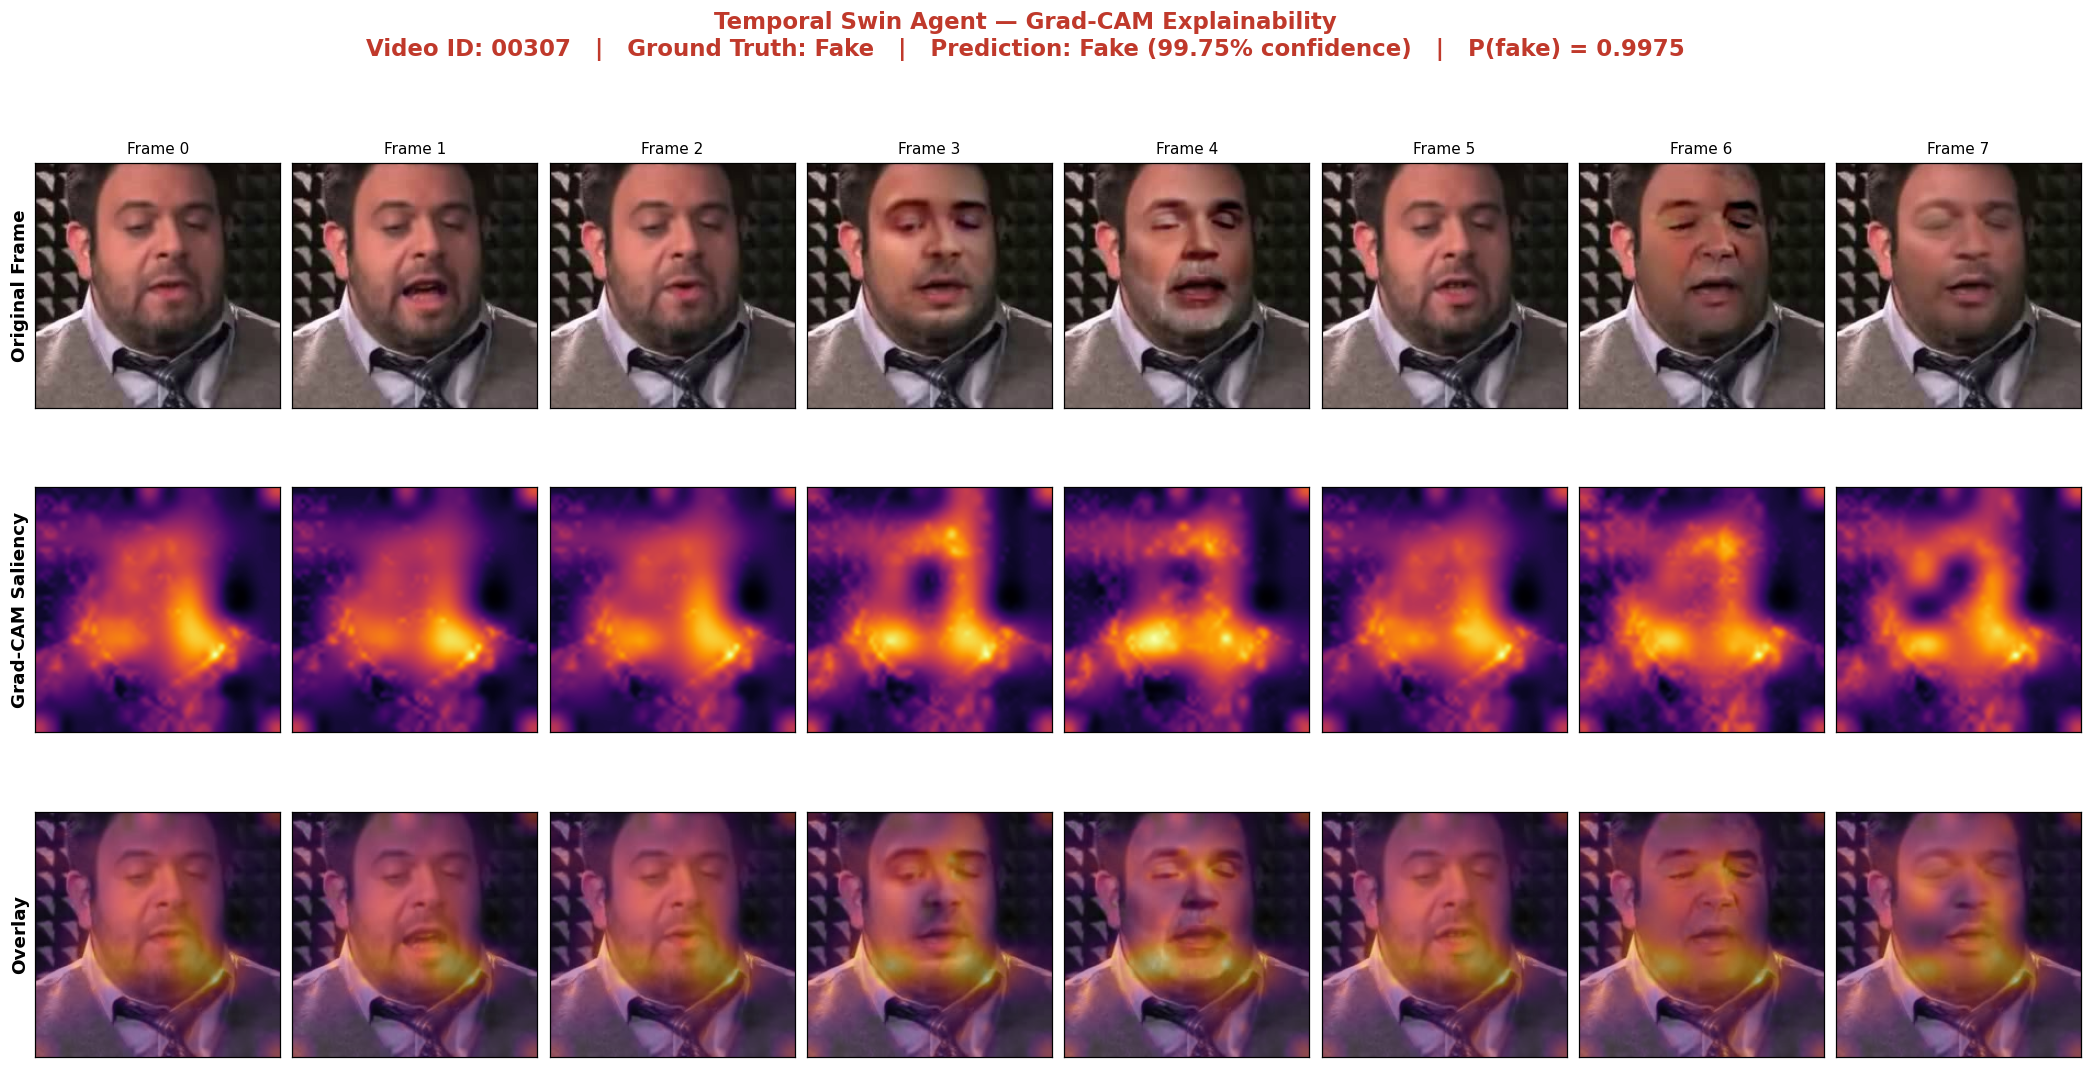

{'video_id': '00307', 'ground_truth': 'Fake', 'prediction': 'Fake', 'confidence': 0.9975398778915405, 'fake_probability': 0.9975398778915405}


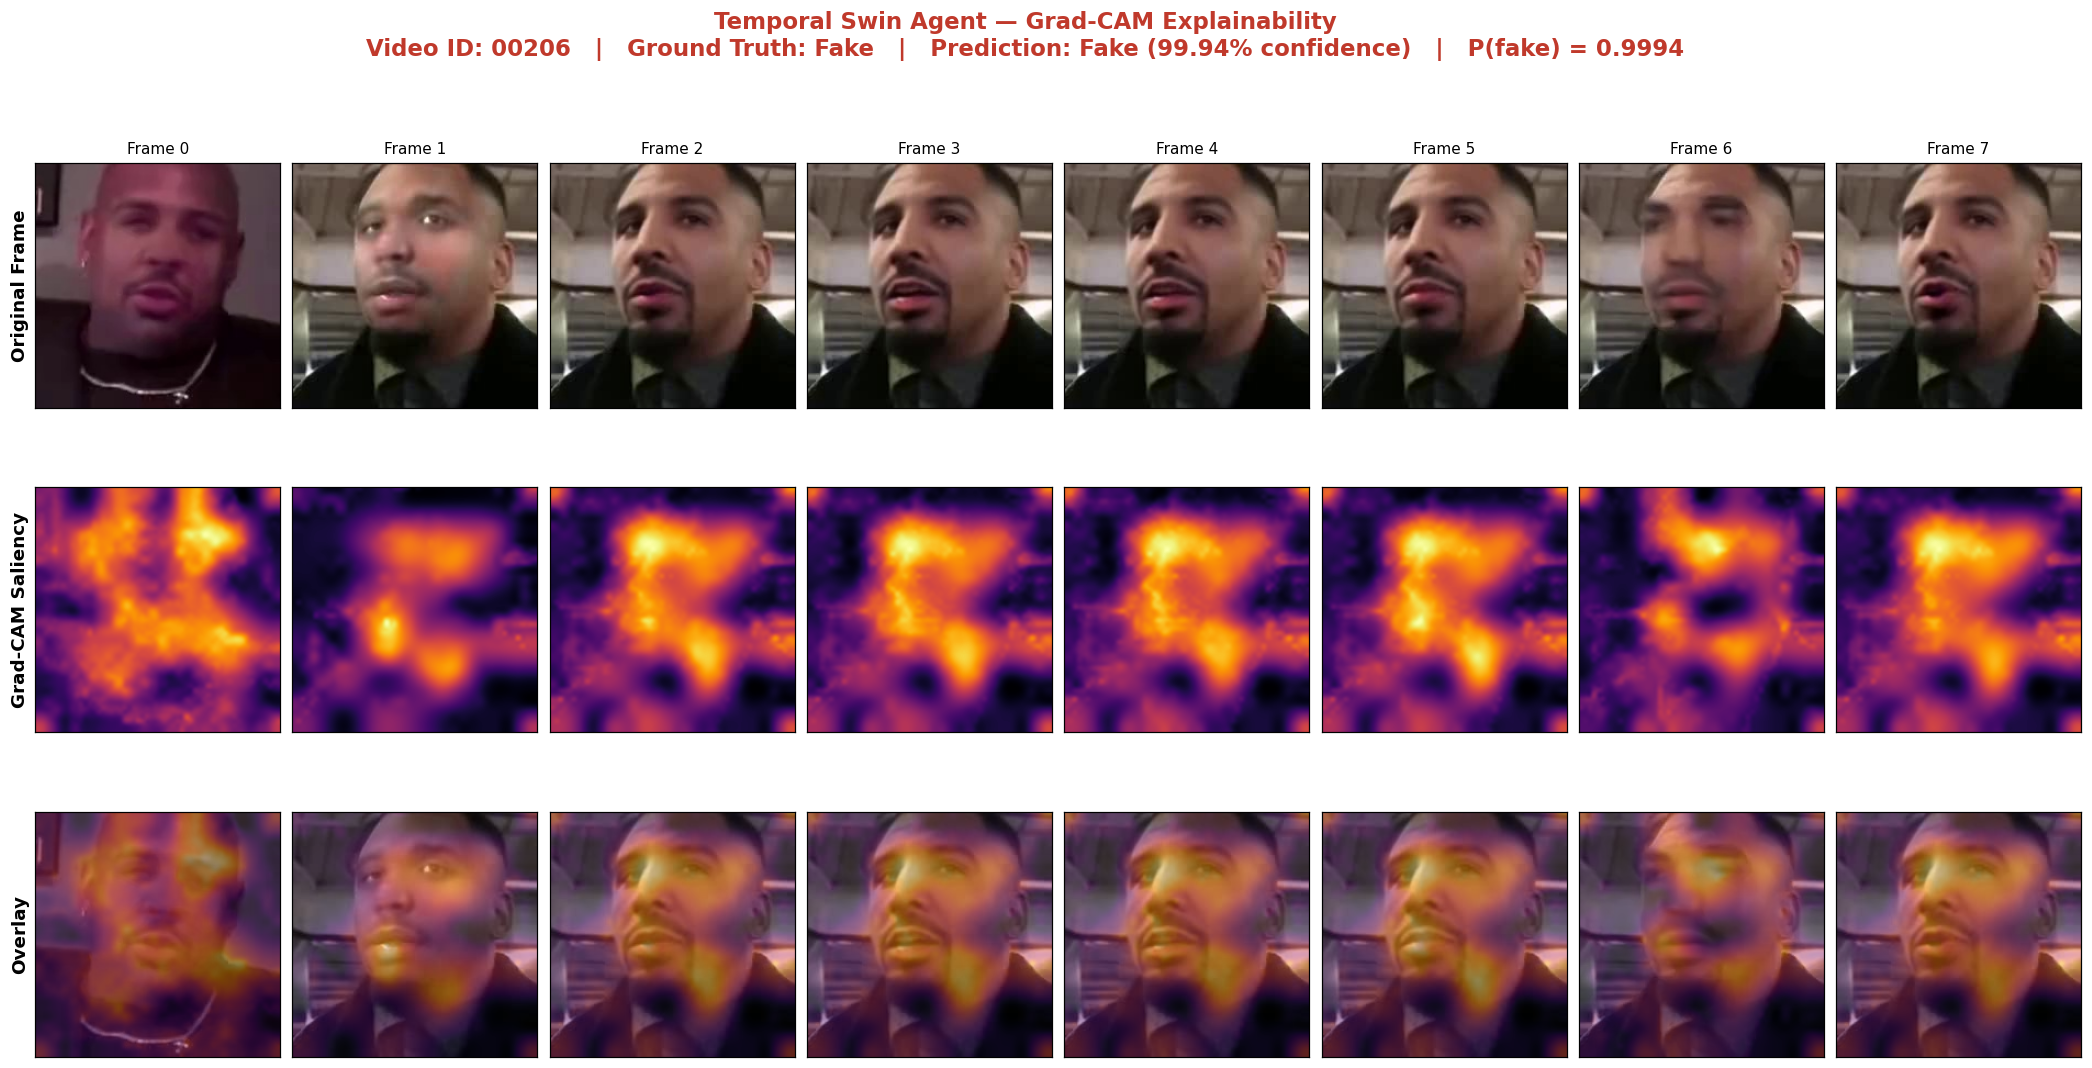

{'video_id': '00206', 'ground_truth': 'Fake', 'prediction': 'Fake', 'confidence': 0.9994292855262756, 'fake_probability': 0.9994292855262756}


In [27]:
import random


def get_sample(split="test", index=None, prefer_label=None):
    """Fetch a sample dict from temporal_cache. Works with any split/index/label combo."""
    samples = temporal_cache.get(split, [])
    if not samples:
        raise ValueError(f"No samples found in temporal_cache['{split}'].")
    if index is not None:
        return samples[index % len(samples)]
    pool = [s for s in samples if s["label"] == prefer_label] if prefer_label is not None else samples
    pool = pool if pool else samples
    return random.choice(pool)


# Demo 1: a random Fake sample from the test set
fake_sample = get_sample(split="test", prefer_label=1)
result_fake = visualize_clip(fake_sample, model, device)
print(result_fake)

# Demo 2: a random Real sample from the test set, to compare saliency patterns
real_sample = get_sample(split="test", prefer_label=0)
result_real = visualize_clip(real_sample, model, device)
print(result_real)


### Engineering Audit: Label & Weighting Diagnostic
This cell verifies the label mapping, calculates the correct theoretical `pos_weight`, and inspects the raw logit distribution to identify the root cause of the class collapse.

--- Data Integrity Audit ---

--- Label Mapping Audit ---
Batch Label Shape: torch.Size([16])
Unique labels in test batch: [1]

--- Weighting Audit ---
Training Manifest - Real (0): 700, Fake (1): 14394
Correct pos_weight (Real/Fake): 0.0486

--- Logit Distribution Audit ---
Logit Mean: 6.6532
Logit Std:  0.8218


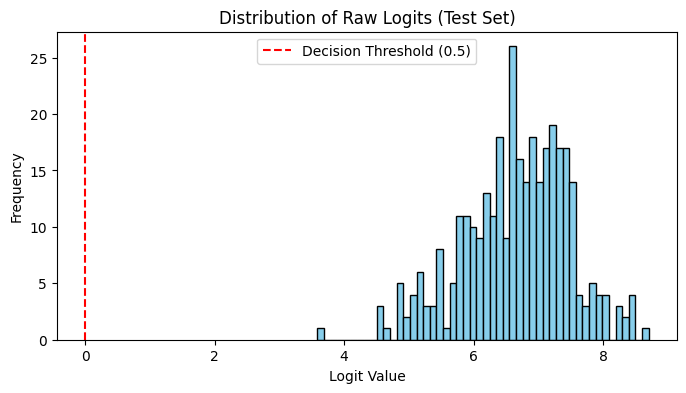

In [50]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# --- 1. Load DataFrames for Audit ---
print("--- Data Integrity Audit ---")
MANIFEST_DIR = Path("/content/drive/MyDrive/FakeAVCeleb_v1.2/manifests")
t_df = pd.read_csv(MANIFEST_DIR / "train.csv")

# --- 2. Label Verification ---
print("\n--- Label Mapping Audit ---")
sample_batch = next(iter(test_loader))
frames, batch_labels = sample_batch['frames'], sample_batch['label']
print(f"Batch Label Shape: {batch_labels.shape}")
print(f"Unique labels in test batch: {torch.unique(batch_labels).tolist()}")

# --- 3. pos_weight Mathematical Audit ---
counts = t_df['label'].value_counts().to_dict()
r, f = counts.get(0, 1), counts.get(1, 1)
# Theory: BCEWithLogitsLoss pos_weight should be (num_negative / num_positive)
# Here Real=0 (neg), Fake=1 (pos). So pos_weight = Real / Fake
theoretical_pos_weight = r / f

print(f"\n--- Weighting Audit ---")
print(f"Training Manifest - Real (0): {r}, Fake (1): {f}")
print(f"Correct pos_weight (Real/Fake): {theoretical_pos_weight:.4f}")

if 'criterion' in globals() and isinstance(criterion, torch.nn.BCEWithLogitsLoss):
    current_pos_weight = criterion.pos_weight.item()
    print(f"Active pos_weight in criterion: {current_pos_weight:.4f}")
    # Note: If your code used weight_real/weight_fake, that equals (f/r), which is INVERTED.
    if abs(current_pos_weight - theoretical_pos_weight) > 1e-4:
        print("CRITICAL: pos_weight is mathematically INVERTED or incorrect!")

# --- 4. Logit Distribution Audit ---
model.eval()
all_logits = []
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        if i > 20: break
        out = model(batch['frames'].to(device))
        all_logits.extend(out.cpu().numpy().flatten())

all_logits = np.array(all_logits)
print(f"\n--- Logit Distribution Audit ---")
print(f"Logit Mean: {all_logits.mean():.4f}")
print(f"Logit Std:  {all_logits.std():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(all_logits, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title("Distribution of Raw Logits (Test Set)")
plt.xlabel("Logit Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Model Export & Checkpoint Management

The training loop above already saves a minimal checkpoint (`model_state_dict`,
`optimizer_state_dict`, `epoch`, `validation_loss`) to `CHECKPOINT_PATH` every time validation
loss improves — that behaviour is untouched.

This section adds a **complete, backward-compatible** `save_checkpoint()` / `load_checkpoint()`
pair that layers the full set of required metadata (scheduler states, training/validation
metrics, class names, image size, model name, timestamp, PyTorch version, random seed, and the
full training configuration) on top of those same original keys, so any code that only reads
`model_state_dict` / `optimizer_state_dict` / `epoch` / `validation_loss` keeps working
unmodified. It then re-saves the final checkpoint with the real test-set metrics from the
evaluation section above, and verifies it immediately by reloading it from disk.


In [31]:
import torch
import logging
import sys
from pathlib import Path
from datetime import datetime

# Configure local logger for this cell
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

# Fix for PyTorch 2.6+ weights_only=True security restriction
if hasattr(torch.serialization, 'add_safe_globals'):
    import torch.torch_version
    torch.serialization.add_safe_globals([torch.torch_version.TorchVersion])

# Define checkpoint path if not already in globals
if 'CHECKPOINT_PATH' not in globals():
    CHECKPOINT_PATH = "/content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/temporal_agent_checkpoint.pth"

CLASS_NAMES = ["Real", "Fake"]
IMAGE_SIZE = 224
NUM_CLASSES = 1
MODEL_NAME = "TemporalSwinAgent(swin_t)"
RANDOM_SEED = 42


def save_checkpoint(
    path,
    model,
    optimizer=None,
    warmup_scheduler=None,
    cosine_scheduler=None,
    epoch=None,
    training_loss=None,
    validation_loss=None,
    validation_metrics=None,
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    num_classes=NUM_CLASSES,
    model_name=MODEL_NAME,
    random_seed=RANDOM_SEED,
    extra_config=None,
):
    """
    Saves a fully self-describing checkpoint.

    Backward compatible: 'model_state_dict', 'optimizer_state_dict', 'epoch' and
    'validation_loss' are always present with the exact same meaning as the
    training loop's original torch.save(...) call, so existing loaders (e.g. the
    evaluation cell above) keep working without any change.
    """
    validation_metrics = validation_metrics or {}
    checkpoint = {
        # --- original keys, unchanged in meaning (backward compatibility) ---
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "validation_loss": validation_loss,
        # --- extended metadata ---
        "scheduler_state_dict": {
            "warmup": warmup_scheduler.state_dict() if warmup_scheduler is not None else None,
            "cosine": cosine_scheduler.state_dict() if cosine_scheduler is not None else None,
        },
        "training_loss": training_loss,
        "validation_accuracy": validation_metrics.get("Accuracy"),
        "validation_precision": validation_metrics.get("Precision"),
        "validation_recall": validation_metrics.get("Recall (Sens.)"),
        "validation_f1_score": validation_metrics.get("F1 Score"),
        "validation_auc": validation_metrics.get("ROC-AUC"),
        "class_names": list(class_names),
        "image_size": image_size,
        "number_of_classes": num_classes,
        "model_name": model_name,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "pytorch_version": torch.__version__,
        "random_seed": random_seed,
        "training_config": extra_config or {},
    }

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, path)
    logger.info(f"Checkpoint saved to: {path}")
    return path


def load_checkpoint(path, model, optimizer=None, warmup_scheduler=None, cosine_scheduler=None, map_location=None):
    """Loads a checkpoint saved by save_checkpoint() (or the original training-loop format)."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    resolved_map_location = map_location or (device if "device" in globals() else "cpu")
    # Use weights_only=False to allow loading metadata classes in 2.6+
    checkpoint = torch.load(path, map_location=resolved_map_location, weights_only=False)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    sched_state = checkpoint.get("scheduler_state_dict")
    if isinstance(sched_state, dict):
        if warmup_scheduler is not None and sched_state.get("warmup") is not None:
            warmup_scheduler.load_state_dict(sched_state["warmup"])
        if cosine_scheduler is not None and sched_state.get("cosine") is not None:
            cosine_scheduler.load_state_dict(sched_state["cosine"])

    logger.info(f"Checkpoint loaded from: {path} (epoch={checkpoint.get('epoch')})")
    return checkpoint


def verify_checkpoint(path):
    """Reloads the checkpoint from disk (fresh read, cpu) and prints an integrity report."""
    path = Path(path)
    # Use weights_only=False to allow loading metadata classes in 2.6+
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)

    required_keys = [
        "model_state_dict", "optimizer_state_dict", "scheduler_state_dict", "epoch",
        "training_loss", "validation_loss", "validation_accuracy", "validation_precision",
        "validation_recall", "validation_f1_score", "validation_auc", "class_names",
        "image_size", "number_of_classes", "model_name", "timestamp",
        "pytorch_version", "random_seed", "training_config",
    ]
    missing = [k for k in required_keys if k not in checkpoint]

    size_mb = path.stat().st_size / (1024 ** 2)
    print("\n" + "=" * 50)
    print("CHECKPOINT VERIFICATION REPORT")
    print("=" * 50)
    print(f"Path             : {path}")
    print(f"Size             : {size_mb:.2f} MB")
    print(f"Model Name       : {checkpoint.get('model_name')}")
    print(f"Epoch            : {checkpoint.get('epoch')}")
    print(f"Timestamp        : {checkpoint.get('timestamp')}")
    print(f"PyTorch Version  : {checkpoint.get('pytorch_version')}")
    print(f"Validation Loss  : {checkpoint.get('validation_loss')}")
    print(f"Validation Acc.  : {checkpoint.get('validation_accuracy')}")
    print(f"Validation F1    : {checkpoint.get('validation_f1_score')}")
    print(f"Validation AUC   : {checkpoint.get('validation_auc')}")
    print(f"Class Names      : {checkpoint.get('class_names')}")
    if missing:
        print(f"WARNING - missing keys: {missing}")
    else:
        print("All expected metadata keys present.")
    print("=" * 50 + "\n")
    return checkpoint


# --- Re-save the final checkpoint with complete metadata ---------------------
_final_training_config = {
    "learning_rate": globals().get("LEARNING_RATE"),
    "weight_decay": globals().get("WEIGHT_DECAY"),
    "batch_size": globals().get("BATCH_SIZE"),
    "num_frames": globals().get("NUM_FRAMES"),
    "epochs": globals().get("EPOCHS"),
    "accumulation_steps": globals().get("ACCUMULATION_STEPS"),
}

_final_epoch = globals().get("checkpoint", {}).get("epoch") if isinstance(globals().get("checkpoint"), dict) else None
if _final_epoch is None:
    _final_epoch = globals().get("EPOCHS", 1) - 1

saved_path = save_checkpoint(
    CHECKPOINT_PATH,
    model=model,
    optimizer=globals().get("optimizer"),
    warmup_scheduler=globals().get("warmup_scheduler"),
    cosine_scheduler=globals().get("cosine_scheduler"),
    epoch=_final_epoch,
    training_loss=globals().get("t_loss"),
    validation_loss=globals().get("avg_v_loss", globals().get("best_val_loss")),
    validation_metrics=globals().get("test_metrics", {}),
    extra_config=_final_training_config,
)

verify_checkpoint(saved_path)


CHECKPOINT VERIFICATION REPORT
Path             : /content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/temporal_agent_checkpoint.pth
Size             : 105.27 MB
Model Name       : TemporalSwinAgent(swin_t)
Epoch            : 9
Timestamp        : 2026-07-06T16:09:09
PyTorch Version  : 2.11.0+cu128
Validation Loss  : None
Validation Acc.  : None
Validation F1    : None
Validation AUC   : None
Class Names      : ['Real', 'Fake']
All expected metadata keys present.



{'model_state_dict': OrderedDict([('backbone.features.0.0.weight',
               tensor([[[[-7.7714e-02, -6.3156e-02, -5.5314e-02, -4.5059e-02],
                         [-5.3241e-02, -6.0294e-02, -7.5578e-02, -4.6489e-02],
                         [-3.6096e-02, -3.0547e-02, -6.2279e-02, -6.0420e-02],
                         [-6.9608e-02, -5.1010e-02, -7.9161e-02, -9.5867e-02]],
               
                        [[ 5.2012e-03,  5.2303e-02,  7.5086e-02,  5.7132e-02],
                         [ 4.8983e-02,  5.9171e-02,  5.2654e-02,  6.7656e-02],
                         [ 5.9708e-02,  8.2439e-02,  6.3471e-02,  4.6930e-02],
                         [ 2.1623e-04,  4.7461e-02,  3.6752e-02, -5.3258e-03]],
               
                        [[-2.2026e-02,  1.2930e-02,  2.6962e-02,  1.8438e-02],
                         [ 3.2580e-02,  2.2416e-02,  2.6743e-02,  4.1665e-02],
                         [ 3.0935e-02,  4.0454e-02,  2.9903e-02,  2.9953e-02],
                         [-1.7

## Reusable Inference API

A single entry point, `predict_video(...)`, that:

- Auto-detects GPU vs. CPU.
- Accepts **either** a raw video file (`.mp4`, `.avi`, `.mov`, `.mkv`, `.webm` — sampled with
  OpenCV) **or** a directory of pre-extracted frame images (the format used everywhere else in
  this notebook), sampling the same number of frames used during training (`NUM_FRAMES`).
- Loads the model from a checkpoint via `load_checkpoint()` if no model instance is passed in.
- Returns exactly `{"prediction": ..., "fake_probability": ..., "confidence": ...}`.
- Uses `pathlib`, `logging`, and full exception handling — failures return a dict with
  `prediction=None` and an `"error"` field instead of raising.


In [35]:
import logging
from pathlib import Path
import numpy as np
import cv2
import torch

VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv", ".webm"}
# Standard number of frames used during training
DEFAULT_NUM_FRAMES = 8

def load_frame(path, target_size=(224, 224)):
    """Reads, converts color, and resizes a single local frame."""
    img = cv2.imread(path)
    if img is None:
        return np.zeros((*target_size[::-1], 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, target_size)

def _sample_frames_from_video_file(video_path, num_frames=DEFAULT_NUM_FRAMES, target_size=(224, 224)):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Could not open video file: {video_path}")
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise IOError(f"Video has no readable frames: {video_path}")

    wanted_indices = set(np.linspace(0, total - 1, num_frames, dtype=int).tolist())
    frames, idx = [], 0
    while cap.isOpened() and len(frames) < num_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if idx in wanted_indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, target_size)
            frames.append(frame)
        idx += 1
    cap.release()

    if len(frames) == 0:
        raise IOError(f"No frames could be sampled from: {video_path}")
    while len(frames) < num_frames:
        frames.append(frames[-1])
    return frames[:num_frames]

def _sample_frames_from_directory(dir_path, num_frames=DEFAULT_NUM_FRAMES, target_size=(224, 224)):
    frame_files = sorted(
        f for f in Path(dir_path).iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png")
    )
    if not frame_files:
        raise IOError(f"No frame images found in directory: {dir_path}")
    indices = np.linspace(0, len(frame_files) - 1, num_frames, dtype=int)
    return [load_frame(str(frame_files[i]), target_size) for i in indices]

def predict_video(video_path, model=None, checkpoint_path=None, device=None, num_frames=DEFAULT_NUM_FRAMES):
    """
    Reusable inference API for the Temporal Swin Agent.
    """
    video_path = Path(video_path)
    try:
        resolved_device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if not video_path.exists():
            raise FileNotFoundError(f"Path does not exist: {video_path}")

        if model is None:
            if checkpoint_path is None:
                raise ValueError("Either `model` or `checkpoint_path` must be provided.")
            inference_model = TemporalSwinAgent().to(resolved_device)
            load_checkpoint(checkpoint_path, inference_model, map_location=resolved_device)
        else:
            inference_model = model.to(resolved_device)
        inference_model.eval()

        if video_path.is_dir():
            frames = _sample_frames_from_directory(video_path, num_frames)
        elif video_path.suffix.lower() in VIDEO_EXTENSIONS:
            frames = _sample_frames_from_video_file(video_path, num_frames)
        else:
            raise ValueError(f"Unsupported input: {video_path}")

        clip = torch.from_numpy(np.array(frames)).permute(0, 3, 1, 2).float().unsqueeze(0).to(resolved_device) / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3, 1, 1).to(resolved_device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3, 1, 1).to(resolved_device)
        norm_clip = (clip - mean) / std

        with torch.no_grad():
            logits = inference_model(norm_clip)
            fake_prob = torch.sigmoid(logits).item()

        prediction = "Fake" if fake_prob >= 0.5 else "Real"
        confidence = fake_prob if fake_prob >= 0.5 else 1 - fake_prob

        return {
            "prediction": prediction,
            "fake_probability": round(float(fake_prob), 6),
            "confidence": round(float(confidence), 6),
        }
    except Exception as e:
        return {"prediction": None, "error": str(e)}